In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../notebooks/IPL Ball-by-Ball.csv")
df.head()


,id,inning,over,ball,batsman,non_striker,bowler,batsman_runs,extra_runs,total_runs,non_boundary,is_wicket,dismissal_kind,player_dismissed,fielder,extras_type,batting_team,bowling_team
0,335982,1,6,5,RT Ponting,BB McCullum,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
1,335982,1,6,6,BB McCullum,RT Ponting,AA Noffke,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
2,335982,1,7,1,BB McCullum,RT Ponting,Z Khan,0,0,0,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
3,335982,1,7,2,BB McCullum,RT Ponting,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore
4,335982,1,7,3,RT Ponting,BB McCullum,Z Khan,1,0,1,0,0,NaN,NaN,NaN,NaN,Kolkata Knight Riders,Royal Challengers Bangalore


In [3]:
top_batsmen = (
    df.groupby('batsman')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_batsmen


batsman
V Kohli           5878
SK Raina          5368
DA Warner         5254
RG Sharma         5230
S Dhawan          5197
AB de Villiers    4849
CH Gayle          4772
MS Dhoni          4632
RV Uthappa        4607
G Gambhir         4217
Name: batsman_runs, dtype: int64

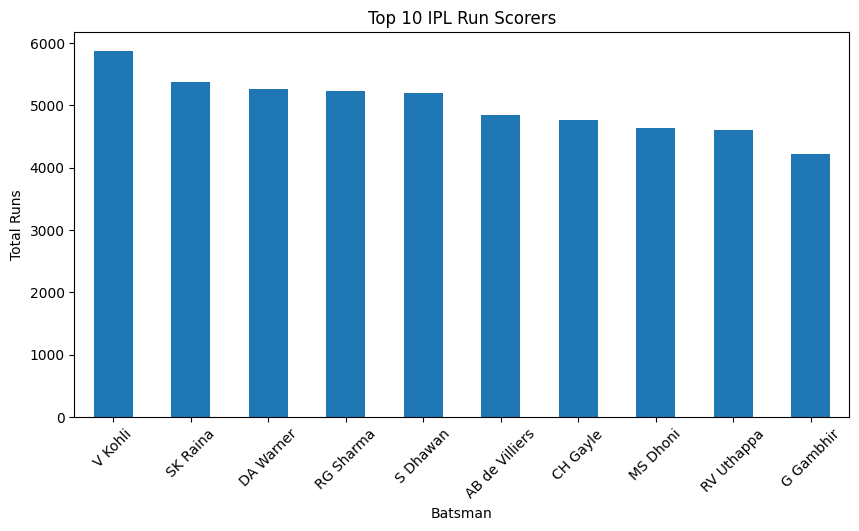

In [5]:
plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar')
plt.title("Top 10 IPL Run Scorers")
plt.xlabel("Batsman")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()


In [6]:
batsman_balls = df.groupby('batsman')['ball'].count()
batsman_runs = df.groupby('batsman')['batsman_runs'].sum()

strike_rate = (batsman_runs / batsman_balls) * 100
strike_rate = strike_rate.sort_values(ascending=False)

strike_rate.head(10)


batsman
B Stanlake         250.000000
Umar Gul           205.263158
RS Sodhi           200.000000
Shahid Afridi      176.086957
I Malhotra         175.000000
TU Deshpande       175.000000
AD Russell         171.995465
LJ Wright          168.253968
Abdul Samad        168.181818
KMDN Kulasekara    166.666667
dtype: float64

In [7]:
#Top 10 Most Wickets Taken (Top Bowlers)
valid_wickets = df[df['dismissal_kind'] != 'run out']
bowler_wickets = valid_wickets.groupby('bowler')['is_wicket'].sum().sort_values(ascending=False)

top_bowlers = bowler_wickets.head(10)
top_bowlers


bowler
SL Malinga         170
A Mishra           160
PP Chawla          156
DJ Bravo           153
Harbhajan Singh    150
R Ashwin           138
B Kumar            136
SP Narine          127
YS Chahal          121
UT Yadav           119
Name: is_wicket, dtype: int64

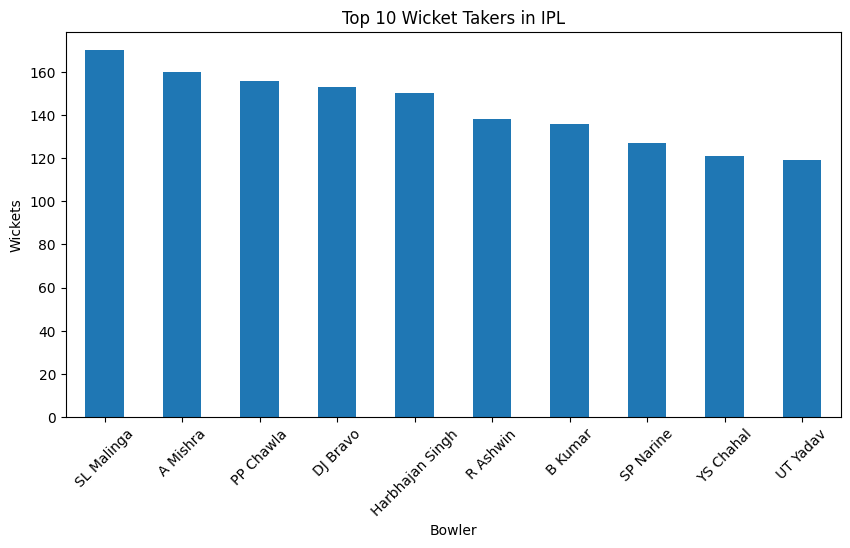

In [8]:
#visualize top wicketkeepers
plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar')
plt.title("Top 10 Wicket Takers in IPL")
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.xticks(rotation=45)
plt.show()


In [10]:
#extra analysis(white,dot,no ball)
df['extras_type'].value_counts()

extras_type
wides      5858
legbyes    3107
noballs     758
byes        508
penalty       2
Name: count, dtype: int64

In [13]:
#Team-wise Total Runs (Which team scored the most runs overall?)
team_runs = df.groupby('batting_team')['total_runs'].sum().sort_values(ascending=False)
team_runs



batting_team
Mumbai Indians                 32286
Royal Challengers Bangalore    30214
Kings XI Punjab                30017
Kolkata Knight Riders          29383
Chennai Super Kings            28363
Rajasthan Royals               24507
Delhi Daredevils               24285
Sunrisers Hyderabad            19332
Deccan Chargers                11463
Pune Warriors                   6358
Delhi Capitals                  5296
Gujarat Lions                   4856
Rising Pune Supergiant          2470
Rising Pune Supergiants         2063
Kochi Tuskers Kerala            1901
Name: total_runs, dtype: int64

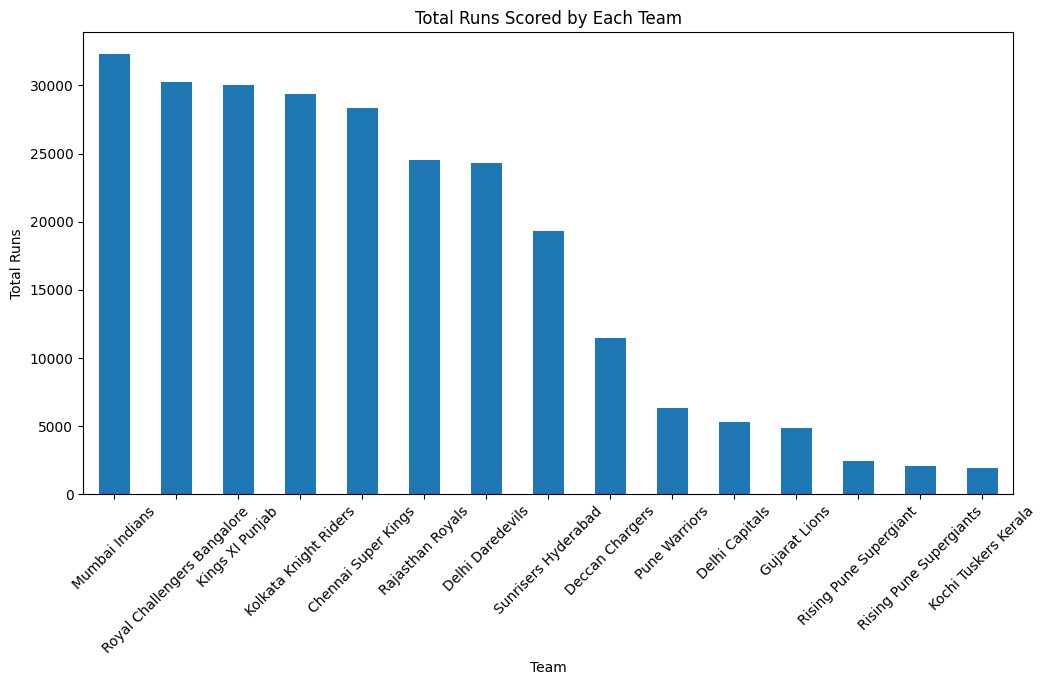

In [14]:
#visualizing it
plt.figure(figsize=(12,6))
team_runs.plot(kind='bar')
plt.title("Total Runs Scored by Each Team")
plt.xlabel("Team")
plt.ylabel("Total Runs")
plt.xticks(rotation=45)
plt.show()


In [15]:
#Step 8 — Over-wise Run Rate (Most dangerous overs)
over_runs = df.groupby('over')['total_runs'].mean()
over_runs


over
0     0.956115
1     1.135251
2     1.280650
3     1.319624
4     1.328280
5     1.338035
6     1.081728
7     1.155609
8     1.204235
9     1.197077
10    1.236719
11    1.266958
12    1.279013
13    1.327945
14    1.382652
15    1.419120
16    1.494871
17    1.574620
18    1.618099
19    1.758837
Name: total_runs, dtype: float64

In [16]:
#most dangerous bowlers

bowler_runs = df.groupby('bowler')['total_runs'].sum()
bowler_balls = df.groupby('bowler').size()
economy = (bowler_runs / bowler_balls) * 6
economy.sort_values().head(10)


bowler
AC Gilchrist     0.000000
NB Singh         4.320000
AS Roy           4.400000
Sachin Baby      4.800000
AM Rahane        5.000000
SS Mundhe        5.142857
LA Carseldine    5.142857
DJ Thornely      5.454545
DA Warner        6.000000
M Manhas         6.000000
dtype: float64

In [20]:
#Top 10 Batsmen by Strike Rate

#Strike Rate = (Runs Scored / Balls Faced) × 100
# Count balls faced (ignore wides because they don't count as balls)
balls_faced = df[df['extras_type'] != 'wides'].groupby('batsman').size()

# Total runs scored by each batsman
runs_scored = df.groupby('batsman')['batsman_runs'].sum()

# Combine into one dataframe
sr_df = pd.DataFrame({
    'runs': runs_scored,
    'balls': balls_faced
})

# Keep only batsmen who faced 200+ balls (to avoid unrealistic strike rates)
sr_df = sr_df[sr_df['balls'] >= 200]

# Calculate strike rate
sr_df['strike_rate'] = (sr_df['runs'] / sr_df['balls']) * 100

# Top 10 highest strike rate batsmen
top_strike_rate = sr_df.sort_values('strike_rate', ascending=False).head(10)

top_strike_rate


,runs,balls,strike_rate
batsman,,,
AD Russell,1517,832,182.331731
N Pooran,521,315,165.396825
SP Narine,892,543,164.272560
HH Pandya,1349,847,159.268005
CH Morris,551,349,157.879656
V Sehwag,2728,1755,155.441595
GJ Maxwell,1505,973,154.676259
RR Pant,2079,1368,151.973684
AB de Villiers,4849,3192,151.911028


In [21]:
#Code to get top boundary hitters (4s and 6s)
# Count 4s (batsman_runs == 4)
fours = df[df['batsman_runs'] == 4].groupby('batsman').size()

# Count 6s (batsman_runs == 6)
sixes = df[df['batsman_runs'] == 6].groupby('batsman').size()

# Combine into a dataframe
boundary_df = pd.DataFrame({
    'fours': fours,
    'sixes': sixes
}).fillna(0)  # fill NaN with 0 for players who may not have 4s or 6s

# Top 10 boundary hitters by total boundaries (4s + 6s)
boundary_df['total_boundaries'] = boundary_df['fours'] + boundary_df['sixes']
top_boundaries = boundary_df.sort_values('total_boundaries', ascending=False).head(10)

top_boundaries


,fours,sixes,total_boundaries
batsman,,,
CH Gayle,384.0,349.0,733.0
V Kohli,504.0,202.0,706.0
DA Warner,510.0,195.0,705.0
S Dhawan,591.0,109.0,700.0
SK Raina,493.0,194.0,687.0
RG Sharma,458.0,214.0,672.0
AB de Villiers,390.0,235.0,625.0
RV Uthappa,454.0,163.0,617.0
SR Watson,376.0,190.0,566.0


In [22]:
#Best Partnerships / Who Batted Together Most
# Create a 'pair' column (sorted alphabetically so pairs match)
df['pair'] = df.apply(
    lambda x: tuple(sorted([x['batsman'], x['non_striker']])),
    axis=1
)

# Calculate runs scored by each pair
pair_runs = df.groupby('pair')['total_runs'].sum().sort_values(ascending=False).head(10)

pair_runs


pair
(AB de Villiers, V Kohli)    3123
(CH Gayle, V Kohli)          2787
(DA Warner, S Dhawan)        2357
(G Gambhir, RV Uthappa)      1906
(MS Dhoni, SK Raina)         1454
(CH Gayle, KL Rahul)         1371
(M Vijay, MEK Hussey)        1367
(BB McCullum, DR Smith)      1363
(KA Pollard, RG Sharma)      1337
(DA Warner, JM Bairstow)     1211
Name: total_runs, dtype: int64

In [23]:
# BOWLERS EDA
bowler_stats = df.groupby('bowler').agg({
    'total_runs': 'sum',
    'ball': 'count',
    'is_wicket': 'sum'
})

bowler_stats['overs'] = bowler_stats['ball'] / 6
bowler_stats['economy_rate'] = bowler_stats['total_runs'] / bowler_stats['overs']

best_bowlers = bowler_stats.sort_values(
    by=['is_wicket', 'economy_rate'],
    ascending=[False, True]
).head(10)

best_bowlers


,total_runs,ball,is_wicket,overs,economy_rate
bowler,,,,,
SL Malinga,3486,2974,188,495.666667,7.032952
DJ Bravo,3869,2846,175,474.333333,8.156711
A Mishra,3913,3233,169,538.833333,7.261986
PP Chawla,4330,3285,164,547.500000,7.908676
Harbhajan Singh,4038,3451,161,575.166667,7.020574
R Ashwin,3756,3327,153,554.500000,6.773670
B Kumar,3333,2795,146,465.833333,7.154919
SP Narine,3208,2824,143,470.666667,6.815864
UT Yadav,3672,2642,137,440.333333,8.339137


In [24]:
#A) Total runs scored by each team
team_runs_scored = (
    df.groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
)

team_runs_scored

#B) Total runs conceded by each team
team_runs_conceded = (
    df.groupby('bowling_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
)

team_runs_conceded

#C) Combine both → Net Run Difference
team_performance = pd.DataFrame({
    'runs_scored': team_runs_scored,
    'runs_conceded': team_runs_conceded
})

team_performance['run_diff'] = (
    team_performance['runs_scored'] - team_performance['runs_conceded']
)

team_performance.sort_values('run_diff', ascending=False)

,runs_scored,runs_conceded,run_diff
Mumbai Indians,32286,31158,1128
Chennai Super Kings,28363,27245,1118
Sunrisers Hyderabad,19332,18934,398
Rising Pune Supergiant,2470,2436,34
Kolkata Knight Riders,29383,29374,9
Rising Pune Supergiants,2063,2113,-50
Delhi Capitals,5296,5351,-55
Kochi Tuskers Kerala,1901,1986,-85
Deccan Chargers,11463,11618,-155
Rajasthan Royals,24507,24705,-198


In [28]:
#step 15 A) Total runs in each match
match_runs = (
    df.groupby('id')['total_runs']
      .sum()
      .sort_values(ascending=False)
)

match_runs.head(10)



id
419137     469
1136604    459
1082641    453
1216527    449
335983     447
1216515    438
501223     433
829795     431
335990     431
1178422    430
Name: total_runs, dtype: int64

In [30]:
# B) Total wickets in each match
match_wickets = (
    df[df['is_wicket'] == 1]
      .groupby('id')['is_wicket']
      .count()
      .sort_values(ascending=False)
)

match_wickets.head(10)


id
1136583    20
419141     20
1082617    20
729307     19
335991     19
1175368    19
980955     19
829779     19
336038     19
733989     19
Name: is_wicket, dtype: int64

In [31]:
# C) Combine runs + wickets
match_summary = pd.DataFrame({
    'total_runs': match_runs,
    'total_wickets': match_wickets
}).fillna(0)

match_summary.sort_values('total_runs', ascending=False).head(10)


,total_runs,total_wickets
id,,
419137,469,10
1136604,459,14
1082641,453,9
1216527,449,8
335983,447,9
1216515,438,12
501223,433,10
829795,431,8
335990,431,12


In [32]:
# D) Identify highest-scoring match + teams
top_match_id = match_runs.idxmax()
df[df['id'] == top_match_id][['batting_team', 'bowling_team']].drop_duplicates()

,batting_team,bowling_team
34616,Chennai Super Kings,Rajasthan Royals
34694,Rajasthan Royals,Chennai Super Kings


In [34]:
#17: Full Match Summary (Text Output)
summary = {
    "Match_ID": int(top_match_id),
    "Teams": df[df['id']==top_match_id][['batting_team','bowling_team']].drop_duplicates().values.tolist(),
    "Total_Runs": int(match_runs[top_match_id]),
    "Total_Wickets": int(match_wickets[top_match_id])
}

summary


{'Match_ID': 419137,
 'Teams': [['Chennai Super Kings', 'Rajasthan Royals'],
  ['Rajasthan Royals', 'Chennai Super Kings']],
 'Total_Runs': 469,
 'Total_Wickets': 10}

In [35]:
#18:Runs per Over in This Match (To Plot Later)
runs_per_over = df[df['id']==top_match_id].groupby('over')['total_runs'].sum()
runs_per_over



over
0     22
1     16
2     16
3     12
4     31
5     31
6     17
7     17
8     17
9     17
10    15
11    26
12    35
13    31
14    42
15    34
16    21
17    34
18    13
19    22
Name: total_runs, dtype: int64

In [37]:
#19: Batsmen Score Chart (for Dashboard)
top_batsmen = (
    df[df['id']==top_match_id]
    .groupby('batsman')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_batsmen


batsman
M Vijay            127
NV Ojha             94
JA Morkel           62
SR Watson           60
MJ Lumb             37
ML Hayden           34
SK Raina            13
AA Jhunjhunwala      7
FY Fazal             4
YK Pathan            4
Name: batsman_runs, dtype: int64

In [38]:
#bowlers wicket chart
top_bowlers = (
    df[(df['id']==top_match_id) & (df['player_dismissed'].notna())]
    .groupby('bowler')['player_dismissed']
    .count()
    .sort_values(ascending=False)
    .head(10)
)
top_bowlers


bowler
SR Watson         3
DE Bollinger      2
JA Morkel         2
M Muralitharan    1
SB Wagh           1
SK Warne          1
Name: player_dismissed, dtype: int64

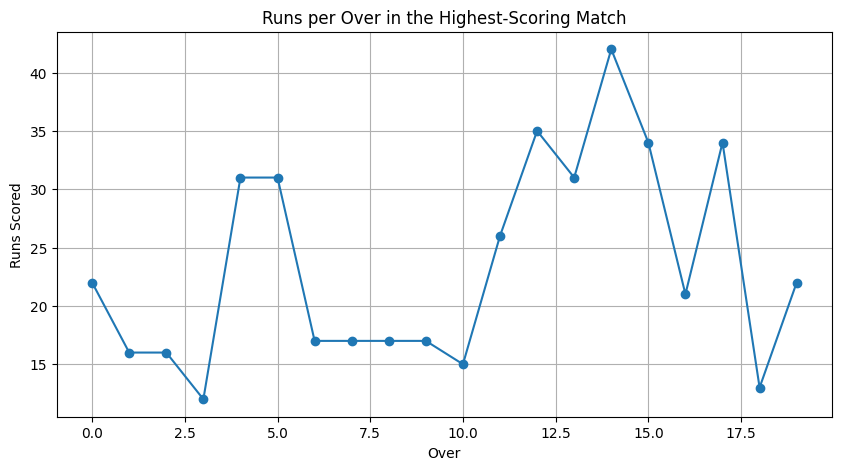

In [39]:
#visualization Plot: Runs per Over (Highest-Scoring Match)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(runs_per_over.index, runs_per_over.values, marker='o')
plt.xlabel("Over")
plt.ylabel("Runs Scored")
plt.title("Runs per Over in the Highest-Scoring Match")
plt.grid(True)
plt.show()


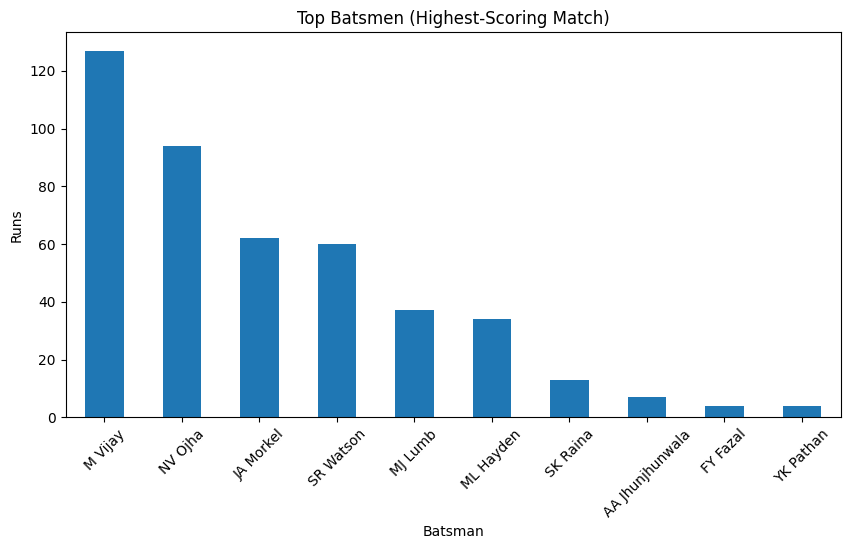

In [41]:
#Plot: Top Batsmen in That Match
plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar')
plt.xlabel("Batsman")
plt.ylabel("Runs")
plt.title("Top Batsmen (Highest-Scoring Match)")
plt.xticks(rotation=45)
plt.show()


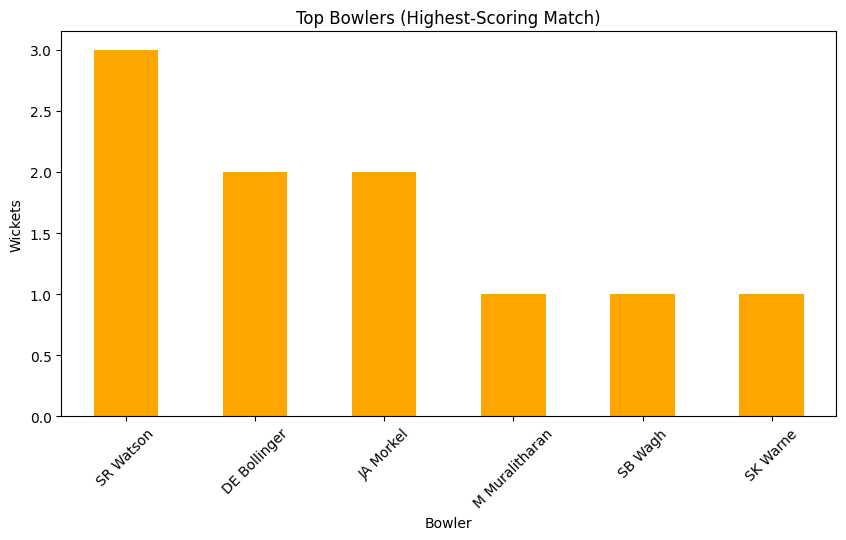

In [42]:
#Plot: Top Bowlers (Wickets in That Match)
plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar', color='orange')
plt.xlabel("Bowler")
plt.ylabel("Wickets")
plt.title("Top Bowlers (Highest-Scoring Match)")
plt.xticks(rotation=45)
plt.show()


In [43]:
#summary
summary_df = pd.DataFrame([summary])
summary_df


,Match_ID,Teams,Total_Runs,Total_Wickets
0,419137,"[[Chennai Super Kings, Rajasthan Royals], [Raj...",469,10
